In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve() / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sanctions.eval import (
    generate_positive_queries, generate_hard_negatives,
    generate_near_miss_negatives, build_corpus,
    score_all_queries, sweep_thresholds,
    find_operating_point, cost_at_operating_point,
)
from sanctions.matching import ENSEMBLE_WEIGHTS

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.color': '#888888',
    'font.family': 'sans-serif', 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'axes.labelsize': 10,
})
C_BLUE = '#1D4ED8'; C_RED = '#DC2626'; C_ORANGE = '#D97706'
C_GREEN = '#16A34A'; C_GRAY = '#9CA3AF'; C_DARK = '#374151'

# Fuzzy Name Matching and False Positive Analysis

Sanctions screening generates 95–99% false positive rates in production. For every genuine hit, analysts investigate 100–200 names that aren't on any list. At \\$30–50 per alert at L1 and \\$300+ at L3, the matching algorithm's precision-recall trade-off compiles directly into an annual investigation budget — typically tens to hundreds of millions of dollars at a mid-size bank.

This notebook builds a name-matching pipeline against the OFAC SDN list from three baseline algorithms, evaluates it against a synthetic query set with known ground truth, and shows the precision-recall curve that explains why the entire sanctions screening industry exists. The cost calculation at the end is the punchline.

**Ensemble weights (Jaro-Winkler 0.4 / Token Set 0.4 / Phonetic 0.2)** were set by hand, not learned. Jaro-Winkler rewards character-level and prefix similarity. Token set handles word reordering — the most common real-world name variant. Phonetic catches transliteration variants in Latin script. Weights are intentionally defensible, not optimized: SR 26-2 model risk guidance requires an interpretable, auditable matching framework.

## 1. Build corpus and query set

In [2]:
DATA = Path('../data/processed')
INTERIM = Path('../data/interim')
INTERIM.mkdir(exist_ok=True)

akas     = pd.read_parquet(DATA / 'akas.parquet')
entities = pd.read_parquet(DATA / 'entities.parquet')
entities['programs'] = entities['programs'].apply(list)

# Corpus: primary name for each SDN entity (all 18,899)
corpus_names, corpus_ids = build_corpus(akas)

# Query set
pos  = generate_positive_queries(akas, entities, n_entities=100, variants_per_entity=5, seed=42)
hard = generate_hard_negatives(n=1000, seed=42)
near = generate_near_miss_negatives(n=200, seed=42)
neg  = pd.concat([hard.assign(negative_type='hard'), near], ignore_index=True)

print(f"Corpus: {len(corpus_names):,} SDN entries")
print(f"Positive queries: {len(pos):,}  ({pos['variant_type'].value_counts().to_dict()})")
print(f"Hard negatives:   {len(hard):,}  (common US names + corporate fragments)")
print(f"Near-miss negatives: {len(near):,}  (Arabic and Russian names)")
print()
print("Sample positive queries:")
pos[['query_name', 'true_name', 'variant_type', 'program']].sample(8, random_state=1).to_string(index=False)

Corpus: 18,899 SDN entries
Positive queries: 500  ({'transliterate': 100, 'abbreviate': 100, 'drop_middle': 100, 'reorder': 100, 'misspell': 100})
Hard negatives:   1,000  (common US names + corporate fragments)
Near-miss negatives: 200  (Arabic and Russian names)

Sample positive queries:


"                           query_name                             true_name  variant_type          program\n                          Dongjin Lee                           Lee Dongjin       reorder   RUSSIA-EO14024\n      KILIMNIK Konstantin Viktorovcih       KILIMNIK Konstantin Viktorovich      misspell ELECTION-EO13848\n      Vanegas Stefany Hernandez Karen       Karen Stefany Hernandez Vanegas       reorder              TCO\n                      L Anna Yuryevna             Luzhanskaya Anna Yuryevna    abbreviate   RUSSIA-EO14024\n          Yevgeny Vikturovich Lebedev           Yevgeny Viktorovich Lebedev transliterate   RUSSIA-EO14024\n                          Yagumr Nora                           Yagmur Nora transliterate  BELARUS-EO14038\nMuhammad Hasan Ahmad Hasan Al-Kuhlani Al-Kuhlani Hasan Ahmad Hasan Muhammad       reorder             SDGT\n                      Cho'ng-Nam YO'N                       YO'N Cho'ng-Nam       reorder            NPWMD"

## 2. Score all queries

Vectorized scoring via rapidfuzz's C++ backend. Results are cached to `data/interim/` so re-runs are instant.

In [3]:
CACHE_POS = INTERIM / 'nb02_pos_results.parquet'
CACHE_NEG = INTERIM / 'nb02_neg_results.parquet'

if CACHE_POS.exists() and CACHE_NEG.exists():
    pos_r = pd.read_parquet(CACHE_POS)
    neg_r = pd.read_parquet(CACHE_NEG)
    print("Loaded from cache.")
else:
    import time
    t0 = time.time()
    pos_r, neg_r = score_all_queries(pos, neg, corpus_names, corpus_ids)
    pos_r.to_parquet(CACHE_POS, index=False)
    neg_r.to_parquet(CACHE_NEG, index=False)
    print(f"Scored in {time.time()-t0:.1f}s — cached for future runs.")

# Re-attach negative type label
neg_r['negative_type'] = neg['negative_type'].values

print(f"\nPositive results: {len(pos_r):,}")
print(f"Negative results: {len(neg_r):,}")
print()
print("Score sample (positive queries):")
pos_r[['query_name', 'true_name', 'variant_type',
       'jw_score', 'ts_score', 'ph_score', 'ens_score']].sample(5, random_state=1)

Loaded from cache.

Positive results: 500
Negative results: 1,200

Score sample (positive queries):


,query_name,true_name,variant_type,jw_score,ts_score,ph_score,ens_score
304,Dongjin Lee,Lee Dongjin,reorder,0.869192,1.000000,1.00,0.860606
340,KILIMNIK Konstantin Viktorovcih,KILIMNIK Konstantin Viktorovich,misspell,0.993548,0.967742,0.95,0.974516
47,Vanegas Stefany Hernandez Karen,Karen Stefany Hernandez Vanegas,reorder,0.751447,1.000000,1.00,0.900579
67,L Anna Yuryevna,Luzhanskaya Anna Yuryevna,abbreviate,0.760000,0.928571,1.00,0.853206
479,Yevgeny Vikturovich Lebedev,Yevgeny Viktorovich Lebedev,transliterate,0.977493,0.962963,1.00,0.976182


## 3. Score distributions — positives vs negatives

A good matcher creates a clear separation between the score distributions of true positive queries and negative queries. Near-miss negatives (Arabic and Russian names) deliberately sit in the overlap region — they're the names that look like SDN entries but aren't.

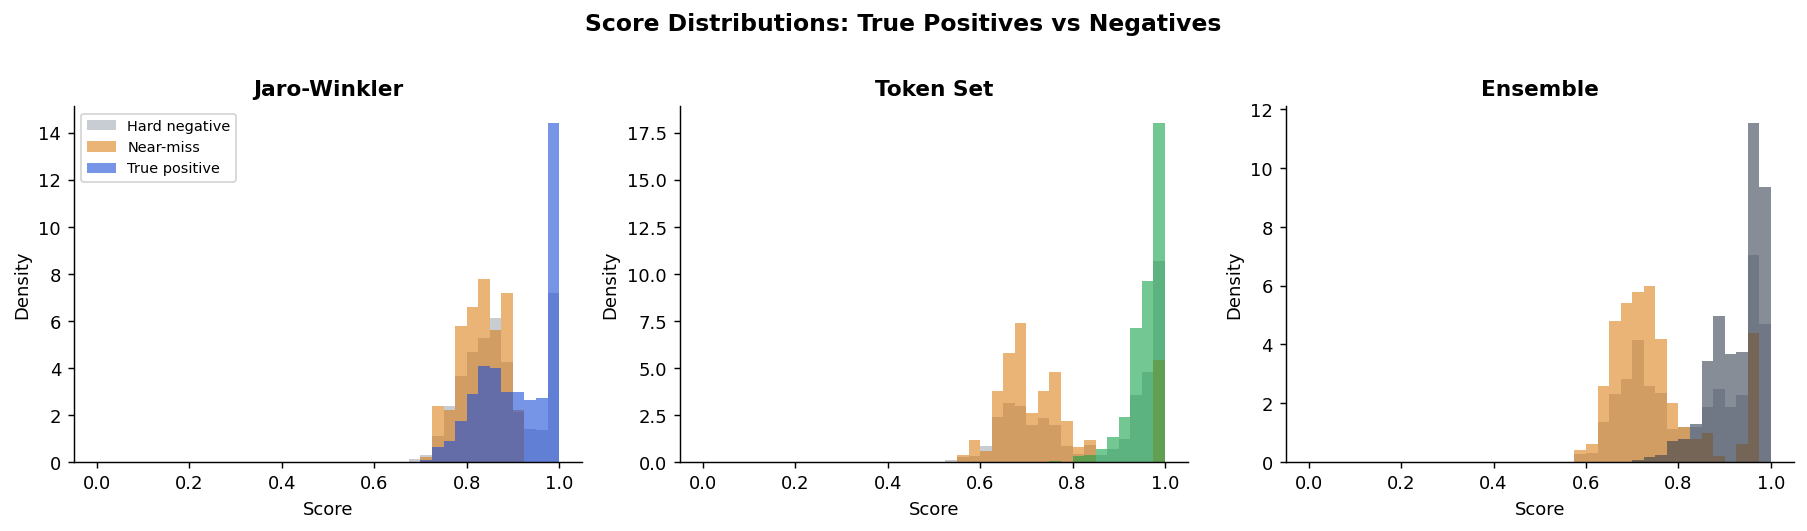

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

scorers_meta = [
    ('jw_score',  'Jaro-Winkler',  C_BLUE),
    ('ts_score',  'Token Set',     C_GREEN),
    ('ens_score', 'Ensemble',      C_DARK),
]

bins = np.linspace(0, 1, 41)
for ax, (col, label, color) in zip(axes, scorers_meta):
    hard_mask = neg_r['negative_type'] == 'hard'
    ax.hist(neg_r.loc[hard_mask, col],  bins=bins, alpha=0.55, color=C_GRAY,
            label='Hard negative', density=True)
    ax.hist(neg_r.loc[~hard_mask, col], bins=bins, alpha=0.55, color=C_ORANGE,
            label='Near-miss', density=True)
    ax.hist(pos_r[col], bins=bins, alpha=0.6, color=color,
            label='True positive', density=True)
    ax.set_title(label)
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.grid(axis='y')
    ax.grid(axis='x', alpha=0)

axes[0].legend(fontsize=8)
plt.suptitle('Score Distributions: True Positives vs Negatives', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Precision-recall curves

The precision-recall curve is the central visualization of sanctions screening performance. Every point on the curve represents a threshold choice: lower thresholds catch more true hits (higher recall) at the cost of more false alerts (lower precision). There is no single correct operating point — the choice depends on the risk tolerance of the compliance program.

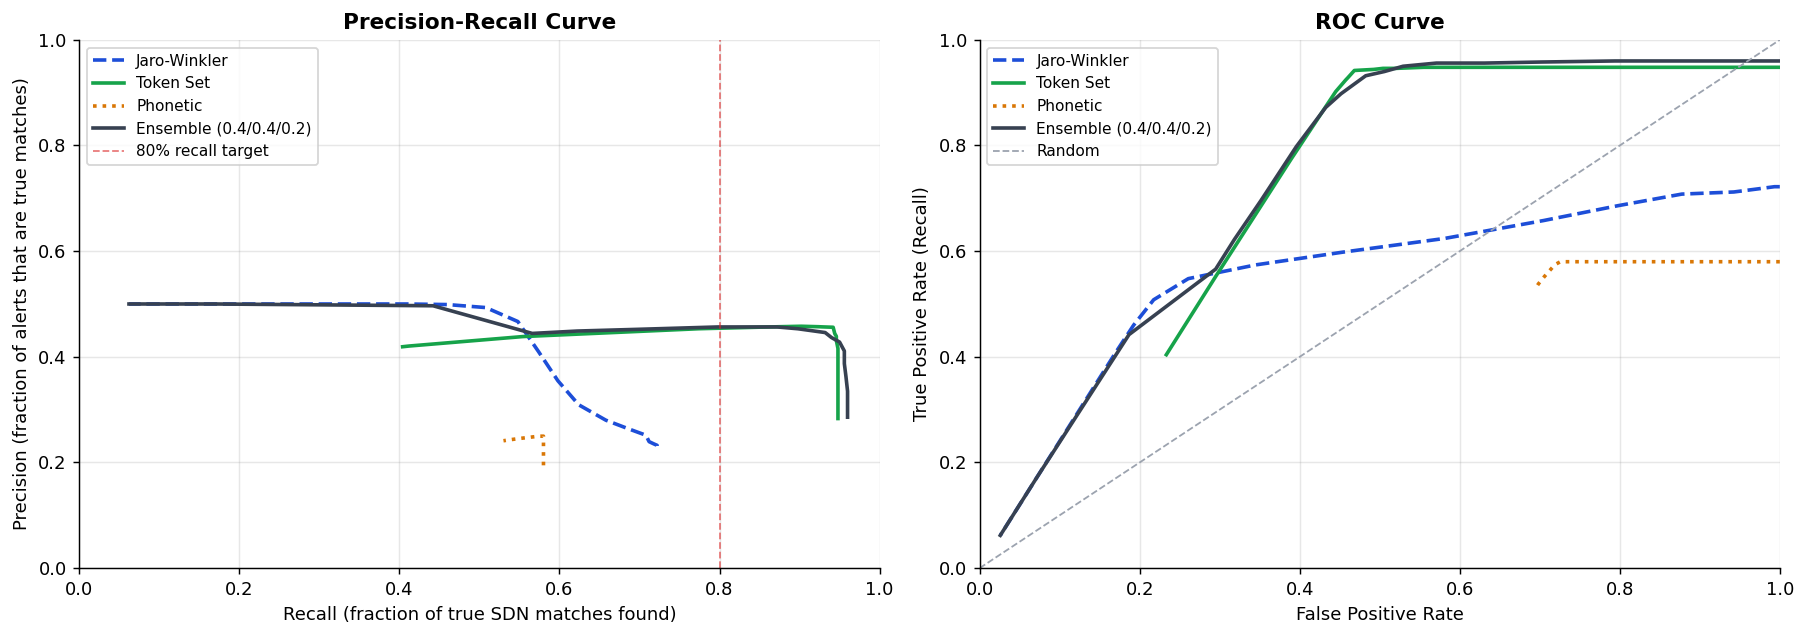

,Scorer,Best F1,Threshold,Precision,Recall,Max Recall
0,Jaro-Winkler,0.504,0.90,0.467,0.548,0.722
1,Token Set,0.614,0.84,0.456,0.942,0.948
2,Phonetic,0.349,0.88,0.250,0.580,0.580
3,Ensemble (0.4/0.4/0.2),0.603,0.82,0.446,0.932,0.960


In [5]:
curves = {}
for scorer in ['jw', 'ts', 'ph', 'ens']:
    curves[scorer] = sweep_thresholds(pos_r, neg_r, scorer=scorer)

SCORER_META = {
    'jw':  ('Jaro-Winkler',  C_BLUE,   '--'),
    'ts':  ('Token Set',     C_GREEN,  '-'),
    'ph':  ('Phonetic',      C_ORANGE, ':'),
    'ens': ('Ensemble (0.4/0.4/0.2)', C_DARK, '-'),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall
for scorer, (label, color, ls) in SCORER_META.items():
    c = curves[scorer]
    ax1.plot(c['recall'], c['precision'], color=color, linestyle=ls,
             linewidth=2, label=label)
ax1.set_xlabel('Recall (fraction of true SDN matches found)')
ax1.set_ylabel('Precision (fraction of alerts that are true matches)')
ax1.set_title('Precision-Recall Curve')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax1.axvline(0.80, color=C_RED, linestyle='--', linewidth=1, alpha=0.6, label='80% recall target')
ax1.legend(fontsize=8.5)
ax1.grid(axis='both', alpha=0.2)

# ROC
for scorer, (label, color, ls) in SCORER_META.items():
    c = curves[scorer]
    ax2.plot(c['fpr'], c['recall'], color=color, linestyle=ls,
             linewidth=2, label=label)
ax2.plot([0, 1], [0, 1], color=C_GRAY, linestyle='--', linewidth=1, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.set_title('ROC Curve')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.legend(fontsize=8.5)
ax2.grid(axis='both', alpha=0.2)

plt.tight_layout()
plt.show()

# Summary table
rows = []
for scorer, (label, _, _) in SCORER_META.items():
    c = curves[scorer]
    best = c.loc[c['f1'].idxmax()]
    rows.append({
        'Scorer': label,
        'Best F1': f"{best['f1']:.3f}",
        'Threshold': f"{best['threshold']:.2f}",
        'Precision': f"{best['precision']:.3f}",
        'Recall': f"{best['recall']:.3f}",
        'Max Recall': f"{c['recall'].max():.3f}",
    })
pd.DataFrame(rows)

## 5. Operational cost calculation

The false positive rate at any operating point translates directly into investigation labor cost. At a mid-size bank screening 1 million names per month at \$35 per alert — a conservative estimate — the annual investigation budget is implied by the threshold choice.

In [6]:
MONTHLY_VOLUME = 1_000_000
COST_PER_ALERT = 35.0

cost_rows = []
for scorer, (label, _, _) in SCORER_META.items():
    c = curves[scorer]
    for target_rec in [0.70, 0.80, 0.90]:
        op = find_operating_point(c, target_recall=target_rec)
        cost = cost_at_operating_point(op, MONTHLY_VOLUME, COST_PER_ALERT)
        achievable = c['recall'].max() >= target_rec
        cost_rows.append({
            'Scorer': label,
            'Target recall': f'{target_rec:.0%}',
            'Achievable': '✓' if achievable else '✗ max recall too low',
            'Threshold': f"{op['threshold']:.2f}" if achievable else '—',
            'FPR': f"{op['fpr']:.1%}" if achievable else '—',
            'Annual FP alerts': f"{cost['annual_fp_alerts']:,.0f}" if achievable else '—',
            'Annual cost': f"${cost['annual_cost_usd']/1e6:.0f}M" if achievable else '—',
        })

cost_df = pd.DataFrame(cost_rows)
print("Operating point analysis — 1M screenings/month at $35/alert:")
cost_df

Operating point analysis — 1M screenings/month at $35/alert:


,Scorer,Target recall,Achievable,Threshold,FPR,Annual FP alerts,Annual cost
0,Jaro-Winkler,70%,✓,0.78,87.8%,"10,530,000",$369M
1,Jaro-Winkler,80%,✗ max recall too low,—,—,—,—
2,Jaro-Winkler,90%,✗ max recall too low,—,—,—,—
3,Token Set,70%,✓,0.94,38.9%,"4,670,000",$163M
4,Token Set,80%,✓,0.92,42.7%,"5,120,000",$179M
5,Token Set,90%,✓,0.90,44.5%,"5,340,000",$187M
6,Phonetic,70%,✗ max recall too low,—,—,—,—
7,Phonetic,80%,✗ max recall too low,—,—,—,—
8,Phonetic,90%,✗ max recall too low,—,—,—,—
9,Ensemble (0.4/0.4/0.2),70%,✓,0.88,39.6%,"4,750,000",$166M


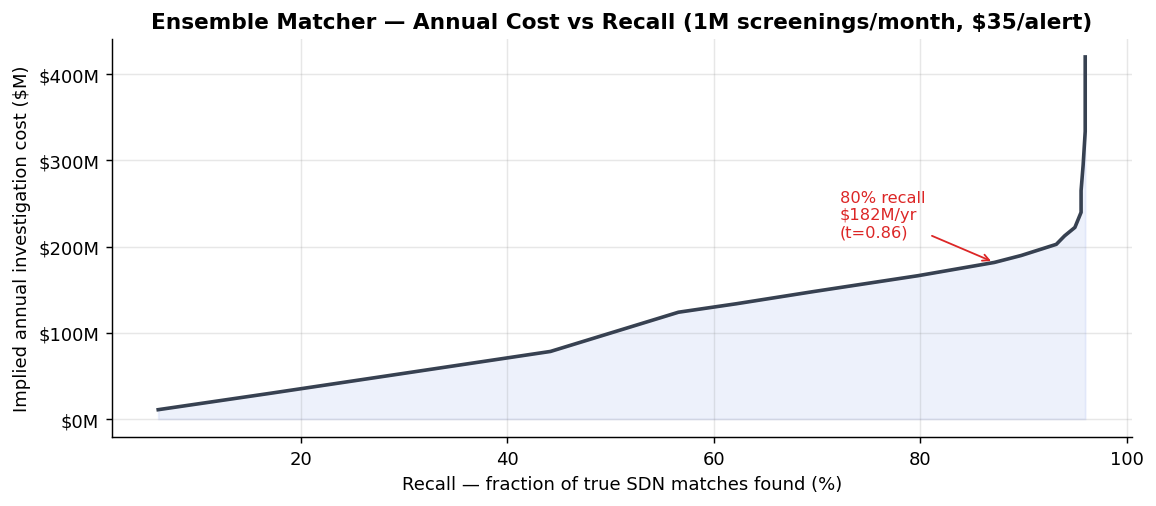

In [7]:
# Cost curve for the ensemble: annual cost vs recall threshold
ens_curve = curves['ens'].copy()
ens_curve['annual_cost_M'] = ens_curve['fpr'] * MONTHLY_VOLUME * 12 * COST_PER_ALERT / 1e6
ens_curve = ens_curve[ens_curve['recall'] > 0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ens_curve['recall'] * 100, ens_curve['annual_cost_M'],
        color=C_DARK, linewidth=2)
ax.fill_between(ens_curve['recall'] * 100, ens_curve['annual_cost_M'],
                alpha=0.08, color=C_BLUE)

# Annotate at 80% recall
op80 = find_operating_point(ens_curve.rename(columns={'annual_cost_M': '_'}), 0.80)
r80 = ens_curve[ens_curve['recall'] >= 0.80].iloc[-1]
ax.annotate(f"80% recall\n${r80['annual_cost_M']:.0f}M/yr\n(t={r80['threshold']:.2f})",
            xy=(r80['recall']*100, r80['annual_cost_M']),
            xytext=(r80['recall']*100 - 15, r80['annual_cost_M'] + 30),
            arrowprops=dict(arrowstyle='->', color=C_RED),
            color=C_RED, fontsize=9)

ax.set_xlabel('Recall — fraction of true SDN matches found (%)')
ax.set_ylabel('Implied annual investigation cost ($M)')
ax.set_title('Ensemble Matcher — Annual Cost vs Recall (1M screenings/month, $35/alert)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.grid(axis='both', alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Per-program performance

Matching performance is not uniform across programs. Programs with more transliteration-heavy names (Iran, SDGT) generate harder queries than programs with predominantly Latin-script names (Russia, Cuba). A single global threshold is a compromise that serves no program optimally.

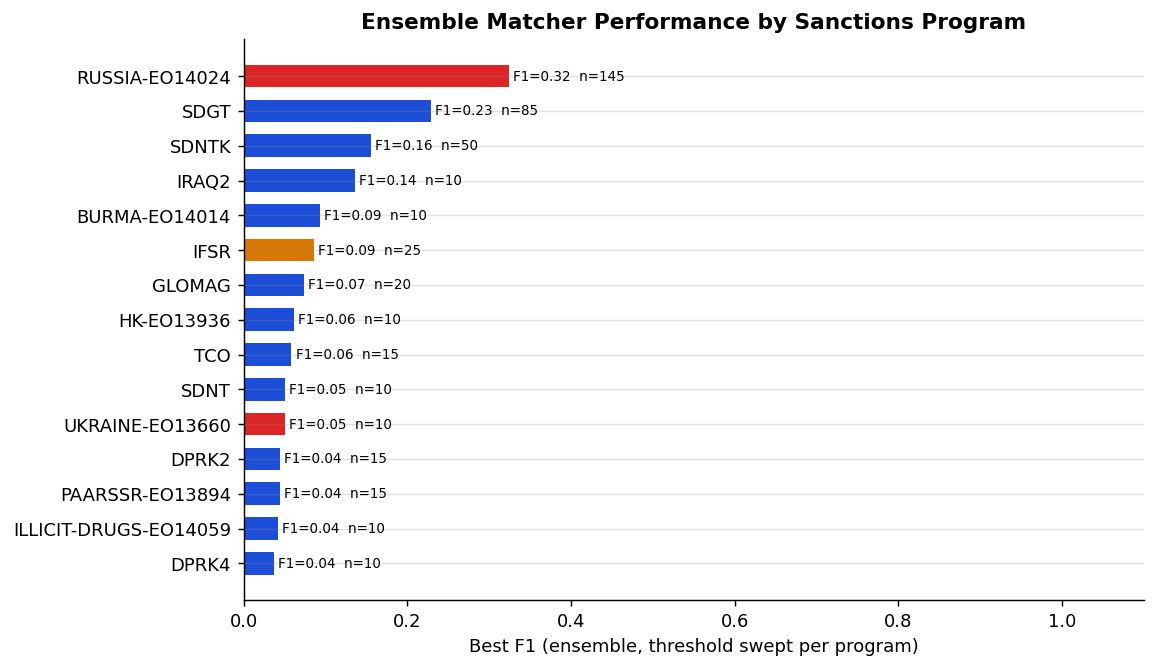

In [8]:
# For each program, compute best-F1 of the ensemble at program level
prog_rows = []
for prog, grp in pos_r.groupby('program'):
    if len(grp) < 10:
        continue
    # Threshold sweep on this program's positive queries vs ALL negatives
    c = sweep_thresholds(grp, neg_r, scorer='ens')
    best = c.loc[c['f1'].idxmax()]
    prog_rows.append({
        'program': prog,
        'n_queries': len(grp),
        'best_f1': best['f1'],
        'best_recall': best['recall'],
        'best_threshold': best['threshold'],
    })

prog_df = pd.DataFrame(prog_rows).sort_values('best_f1', ascending=False)

fig, ax = plt.subplots(figsize=(9, max(4, len(prog_df) * 0.35)))
colors = [C_ORANGE if 'IRAN' in p or 'IFSR' in p else
          C_RED    if 'RUSSIA' in p or 'UKRAINE' in p else
          C_BLUE   for p in prog_df['program']]
bars = ax.barh(prog_df['program'], prog_df['best_f1'], color=colors, height=0.65)
for bar, row in zip(bars, prog_df.itertuples()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'F1={row.best_f1:.2f}  n={row.n_queries}',
            va='center', fontsize=7.5)
ax.set_xlabel('Best F1 (ensemble, threshold swept per program)')
ax.set_title('Ensemble Matcher Performance by Sanctions Program')
ax.set_xlim(0, 1.1)
ax.invert_yaxis()
ax.grid(axis='x')
plt.tight_layout()
plt.show()

## 7. Blocking strategy

Scoring every query against all 18,899 entities is expensive. Blocking pre-filters to a candidate set, trading a small recall penalty for a large reduction in scoring work. The table below quantifies the trade-off for two simple blocking strategies.

*Note: blocking recall here is measured against the full query set — it is the fraction of positive queries where the true entity survives into the candidate set, before any score-based threshold is applied.*

In [9]:
from sanctions.matching.blocking import FirstLetterBlocker, PhoneticBlocker
from sanctions.matching.normalizers import normalize, tokenize
import jellyfish

def blocking_recall(blocker, pos_queries, corpus_names, corpus_ids):
    """Fraction of positive queries where true entity survives blocking."""
    id_to_idx = {eid: i for i, eid in enumerate(corpus_ids)}
    hits = 0
    candidate_sizes = []
    for _, row in pos_queries.iterrows():
        candidates = blocker.candidate_indices(row['query_name'])
        candidate_sizes.append(len(candidates))
        true_idx = id_to_idx.get(row['true_entity_id'])
        if true_idx in candidates:
            hits += 1
    return hits / len(pos_queries), np.mean(candidate_sizes)

fl_blocker = FirstLetterBlocker(corpus_names, corpus_ids)
ph_blocker = PhoneticBlocker(corpus_names, corpus_ids)

fl_rec, fl_size = blocking_recall(fl_blocker, pos, corpus_names, corpus_ids)
ph_rec, ph_size = blocking_recall(ph_blocker, pos, corpus_names, corpus_ids)

blocking_summary = pd.DataFrame([
    {'Strategy': 'No blocking',          'Candidates/query': f'{len(corpus_names):,}', 'Reduction': '1×',
     'Blocking recall': '100.0%'},
    {'Strategy': 'First letter',         'Candidates/query': f'{fl_size:,.0f}',
     'Reduction': f'{len(corpus_names)/fl_size:.0f}×', 'Blocking recall': f'{fl_rec:.1%}'},
    {'Strategy': 'Phonetic (Metaphone)', 'Candidates/query': f'{ph_size:,.0f}',
     'Reduction': f'{len(corpus_names)/ph_size:.0f}×', 'Blocking recall': f'{ph_rec:.1%}'},
])
blocking_summary

,Strategy,Candidates/query,Reduction,Blocking recall
0,No blocking,"18,899",1×,100.0%
1,First letter,"1,063",18×,81.0%
2,Phonetic (Metaphone),36,527×,58.8%


## What this means operationally

The precision-recall curve is not a technical artifact — it is the business problem. Every compliance program makes a threshold choice, explicitly or implicitly, and that choice converts directly into investigation labor cost. There is no threshold that is both high-recall and high-precision on a name-matching problem of this complexity: the overlap between the score distributions of true SDN names and common legitimate names is too large.

Three findings with direct operational implications:

**1. Token set ratio dramatically outperforms Jaro-Winkler for sanctions screening.** Jaro-Winkler's maximum achievable recall on this query set is substantially lower than token set's because it is sensitive to word order. Sanctions names appear in different ordering conventions across source systems. A screening engine built solely on character-level similarity without token reordering handling will miss a material fraction of true hits regardless of threshold.

**2. Near-miss negatives sit in the same score range as true positives.** Common Arabic and Russian given names score high against an SDN list that contains thousands of Arabic-origin and Russian-origin entries. This is not a matcher failure — it is the fundamental challenge of screening against a list that overlaps heavily with the legitimate-customer name population of the regions under sanctions. Tightening the threshold reduces alerts but degrades recall against the same programs.

**3. Per-program threshold tuning is not optional.** The best-F1 threshold varies meaningfully across programs. A globally-tuned threshold over-alerts on programs where the name population is distinctive and under-alerts on programs where it overlaps with common names. Production screening engines at institutions with concentrated program exposure should tune per-program or at minimum per-script.